# Yassin Pellicer Lamla - MIADB 2026/2027
Proyecto de Python para Análisis de Datos

## Inicialización de los dataFrames

In [118]:
import pandas as pd
import numpy as py
import matplotlib as plt
import matplotlib.pyplot as plt

In [119]:
athletes_df = pd.read_csv('atletas.csv')
medals_df = pd.read_csv('medallas.csv')

## 1. Relación entre los datos de entrada

### Análisis

Los dataFrames "atletas" y "medallas" proporcionan la información de las participaciones de cada atleta en los juegos olímpicos. Medallas muestra las participaciones, y Atletas guarda la información de cada atleta participante. Los dataFrames se relacionan con la columna ID, que referencia a cada Atleta con su respectiva participación.

In [120]:
athletes_df.info(); print()
medals_df.info(); print()

<class 'pandas.DataFrame'>
RangeIndex: 135571 entries, 0 to 135570
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      135571 non-null  int64  
 1   Name    135571 non-null  str    
 2   Sex     135571 non-null  str    
 3   Age     129203 non-null  float64
 4   Height  101655 non-null  float64
 5   Weight  100686 non-null  float64
 6   Team    135571 non-null  str    
 7   NOC     135571 non-null  str    
dtypes: float64(3), int64(1), str(4)
memory usage: 8.3 MB

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 8 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   ID      271116 non-null  int64
 1   Games   271116 non-null  str  
 2   Year    271116 non-null  int64
 3   Season  271116 non-null  str  
 4   City    271116 non-null  str  
 5   Sport   271116 non-null  str  
 6   Event   271116 non-null  str  
 7   Medal   39783 non-null   str  
dty

A continuación un listado con nombre del atleta, país, tipo de juegos, años en los que participó y medallas
obtenidas en cada año. Para ello se deben agrupar los dos dataFrames por la columna ID. La salida estará ordenada por número de medallas en orden desdendente.

In [121]:
athlete_medals_df = pd.merge(athletes_df, medals_df, on="ID")

listing = (
  athlete_medals_df
  .groupby(["ID", "Name", "NOC", "Season", "Year"], as_index=False)
  .agg(Medallas=("Medal", lambda x: list(x.dropna())))
)

listing["Total_medallas"] = listing["Medallas"].apply(len)
listing = listing.sort_values("Total_medallas", ascending=False)

print(listing.head(20))

            ID                                Name  NOC  Season  Year  \
39484    28790     Aleksandr Nikolayevich Dityatin  URS  Summer  1980   
130190   94406             Michael Fred Phelps, II  USA  Summer  2008   
130189   94406             Michael Fred Phelps, II  USA  Summer  2004   
5618      4198        Nikolay Yefimovich Andrianov  URS  Summer  1976   
68839    50011      Mariya Kindrativna Horokhovska  URS  Summer  1952   
93916    68189            Willis Augustus Lee, Jr.  USA  Summer  1920   
157226  113912                   Mark Andrew Spitz  USA  Summer  1972   
150714  109161         Borys Anfiyanovych Shakhlin  URS  Summer  1960   
15835    11642      Matthew Nicholas "Matt" Biondi  USA  Summer  1988   
157263  113935               Lloyd Spencer Spooner  USA  Summer  1920   
176280  127501         Mikhail Yakovlevich Voronin  URS  Summer  1968   
40915    29791                Burton Cecil Downing  USA  Summer  1904   
51138    37123                         Konrad Frey 

Con sólo úna de las tablas (p. ej. si sólo dispusiéramos del dataFrame Medals) no se podría saber nunca a quién corresponden las participaciones. Hay algunas preguntas que no se pueden responder a menos que se usen las dos tablas:

- **¿Qué atletas obtuvieron más medallas en cada año?**
  Necesitamos las columnas Name, NOC, y Year y Medal de la segunda

- **¿Cuál es la altura media de los atletas que ganaron una medalla de plata?**
  Necesitamos Height y Medal

- **¿Cuál es la proporción de condecorados entre los participantes de cada país por año?**
  Necesitaríamos las columnas NOC y Medals y Year

**A continuación un gráfico de barras apliadas con el nº de participaciones por país para los 10 países con más participaciones**. Eliminaremos los duplicados entre Atleta, Juegos y País para considerar múltiples participaciones (del mismo atleta) en el mismo año como una única participación (ya que es común que un mismo atleta participe en múltiples categorías de su deporte, como Michael Phelps - ID: 94406 en varios estilos de natación).

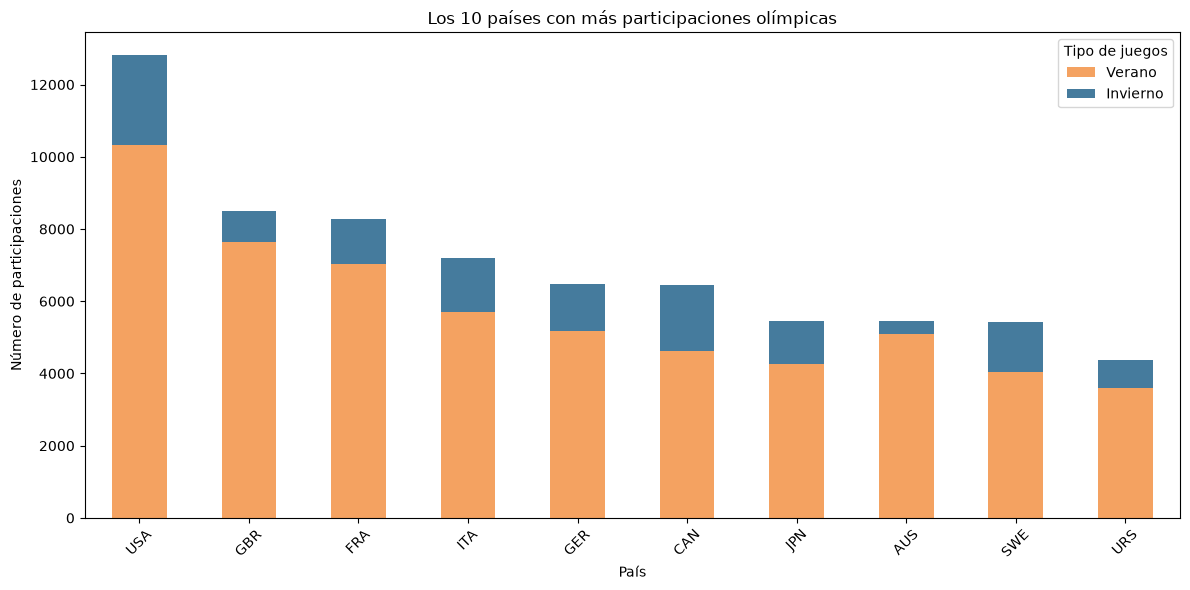

In [127]:
participaciones = (
  athlete_medals_df
  .drop_duplicates(subset=["ID", "NOC", "Games"])
  .groupby(["NOC", "Season"])
  .size()
  .unstack(fill_value=0)
)
participaciones["Total"] = participaciones.sum(axis=1)
top10 = participaciones.nlargest(10, "Total")

ax = top10[["Summer", "Winter"]].rename(
    columns={"Summer": "Verano", "Winter": "Invierno"}
).plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=["#f4a261", "#457b9d"]
)

ax.set_title("Los 10 países con más participaciones olímpicas")
ax.set_xlabel("País")
ax.set_ylabel("Número de participaciones")
ax.legend(title="Tipo de juegos")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


La elección del gráfico de barras apiladas es útil porque permite ver a simple vista que las participaciones en los Juegos de Verano son mucho más abundantes que en los Juegos de Invierno.

```
resumen_participacion(id_atleta, df_medallas)
```
Resume los años de participación de un atleta concreto en intervalos consecutivos y devuelva un diccionario con esa información

In [123]:
def resumen_participacion(id_atleta, df):
  years = sorted(df.loc[df["ID"] == id_atleta, "Year"].unique())

  if not years:
    return {"ID": id_atleta, "participaciones": 0, "intervalos": []}

  intervals = []
  inicio = fin = int(years[0])

  for year in years[1:]:
    year = int(year)

    if year == fin + 4:
      fin = year
    else:
      intervals.append(f"{inicio}-{fin}")
      inicio = fin = year

  intervals.append(f"{inicio}-{fin}")
  return {"ID": id_atleta, "participaciones": len(years), "intervalos": intervals}
  

In [124]:
resumen_participacion(id_atleta=94406, df=medals_df)

{'ID': 94406, 'participaciones': 5, 'intervalos': ['2000-2016']}

## 2. Perfil de los atletas

### Análisis

A continuación se obtendrán las edades medias de los atletas diferenciando entre juegos de verano e invierno. Es interesante ver que la edad de los atletas en el dataFrame es la del año en el que debutan, por lo que para computar años siguientes será importante sumarle +4 en función de los años que han pasado desde su debut.

In [125]:
age_df = athlete_medals_df.copy()

# Extraemos el año de debut de cada atleta
age_df["Debut"] = age_df.groupby("ID")["Year"].transform("min")

# Calculamos para cada participación la edad del atleta
age_df["Age_of_participation"] = (
  age_df["Age"] + age_df["Year"] - age_df["Debut"]
)

# Eliminamos participaciones múltiples
age_df = age_df.drop_duplicates(subset=["ID", "Games"])

edades = (
  age_df
  .groupby("Season", as_index=False)
  .agg(Edad_media=("Age_of_participation", "mean"))
)

print(edades)

   Season  Edad_media
0  Summer   25.908560
1  Winter   25.102371


**Ahora se mostrará un histograma de edades de los 5 países con más atletas participantes**.

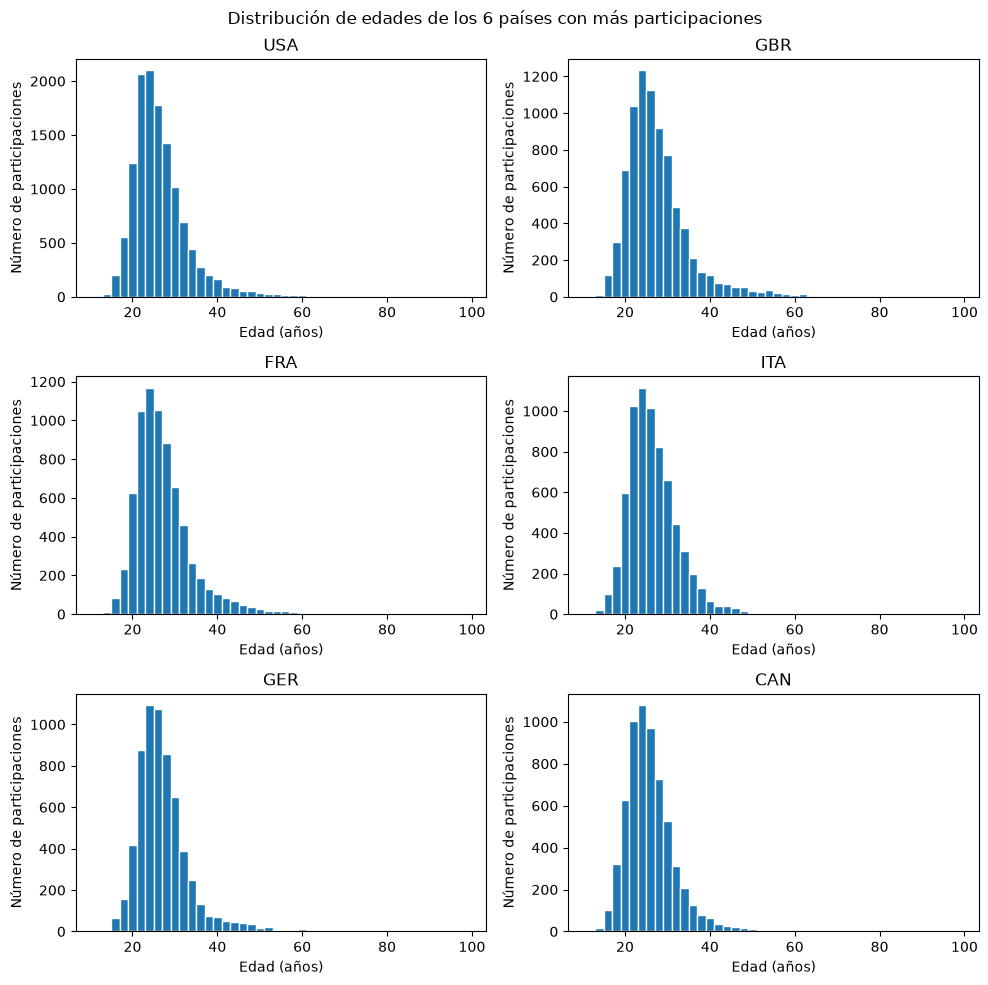

In [126]:
top6_paises = participaciones.nlargest(6, "Total").index

datos = age_df.loc[age_df["NOC"].isin(top6_paises)]
edades_validas = datos["Age_of_participation"].dropna()

bins = range(
  int(edades_validas.min()),
  int(edades_validas.max()) + 3,
  2
)

fig, axes = plt.subplots(
  3, 2, figsize=(10, 10)
)
axes = axes.ravel()

for ax, pais in zip(axes, top6_paises):
  edades_pais = datos.loc[
    datos["NOC"] == pais, "Age_of_participation"
  ].dropna()

  ax.hist(edades_pais, bins=bins, edgecolor="white")
  ax.set_title(pais)
  ax.set_xlabel("Edad (años)")
  ax.set_ylabel("Número de participaciones")

fig.suptitle(
  "Distribución de edades de los 6 países con más participaciones"
)
plt.tight_layout()
plt.show()

**Ahora se mostrará la distribución porcentual entre hombres y mujeres y entre Juegos de Verano e Invierno**

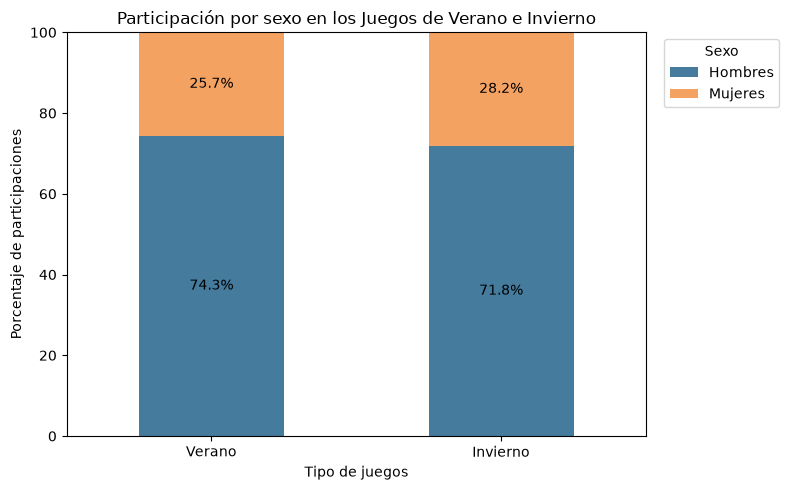

Sex         F       M   Total      % Men    % Women
Season                                             
Summer  40787  118072  158859  74.325030  25.674970
Winter   8054   20539   28593  71.832267  28.167733


In [141]:
segregation = (
  athlete_medals_df
  .drop_duplicates(subset=["ID", "NOC", "Games"])
  .groupby(["Season", "Sex"])
  .size()
  .unstack(fill_value=0)
)

segregation["Total"] = segregation.sum(axis=1)
segregation["% Men"] = (segregation["M"] / segregation["Total"])*100
segregation["% Women"] = (segregation["F"] / segregation["Total"])*100

porcentajes = segregation[["% Men", "% Women"]].rename(
  index={"Summer": "Verano", "Winter": "Invierno"},
  columns={"% Men": "Hombres", "% Women": "Mujeres"}
)

ax = porcentajes.plot(
  kind="bar",
  stacked=True,
  figsize=(8, 5),
  color=["#457b9d", "#f4a261"],
  rot=0
)

for container in ax.containers:
  ax.bar_label(container, fmt="%.1f%%", label_type="center")

ax.set_title("Participación por sexo en los Juegos de Verano e Invierno")
ax.set_xlabel("Tipo de juegos")
ax.set_ylabel("Porcentaje de participaciones")
ax.set_ylim(0, 100)
ax.legend(title="Sexo", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()

print(segregation)

**La elección del diagrama de barras apiladas es conveniente ya que permite ver cómo la suma de la proporción de hombres y mujeres conforma el 100% de participantes**

In [ ]:
women_sports = (
  athlete_medals_df
  .drop_duplicates(subset=["ID", "NOC", "Games"])
  .groupby(["Sport", "Sex"])
  .size()
  .unstack(fill_value=0)
)
women_sports = women_sports[women_sports["F"] > women_sports["M"]]

print(women_sports)

Sex                       F     M
Sport                            
Figure Skating         1116  1066
Synchronized Swimming   728     0
Rhythmic Gymnastics     658     0
Softball                478     0
